# Car_Price Prediction_Supervised_Linear Regression

# Step 1: Read & Load Data

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df =pd.read_csv(r"D:\DATA Practice\car_sales_data For ML.csv")

In [51]:
df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


# Step 2: Data Cleaning & Handle null values

In [52]:
df.isnull()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False


In [53]:
df.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


# Step 3: EDA Process 

## Encoding (one hot Encoding)

<function matplotlib.pyplot.show(close=None, block=None)>

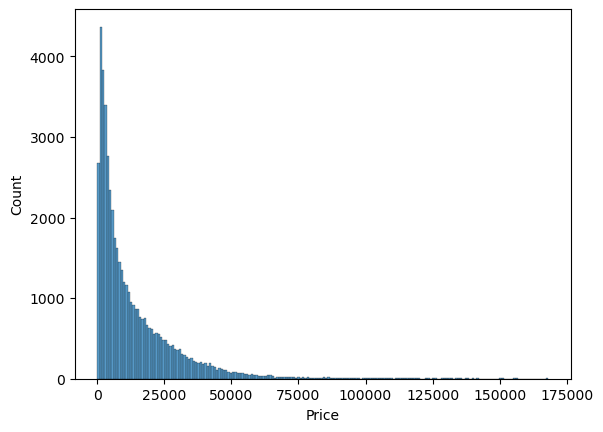

In [55]:
sns.histplot(df["Price"])
plt.show

## Boxplot (Outliers) not necessary just a practice...

<function matplotlib.pyplot.show(close=None, block=None)>

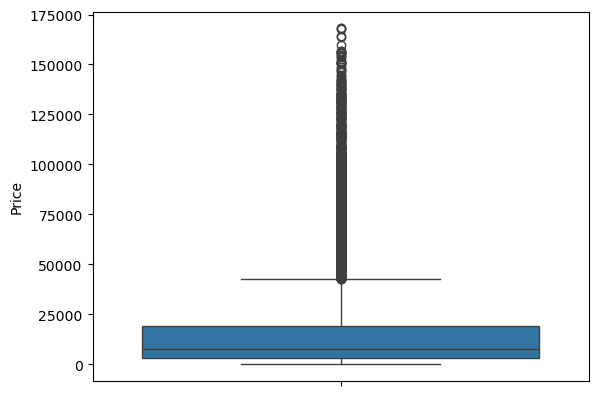

In [56]:
sns.boxplot(y="Price",data = df)
plt.show

## Relation B/W Fuel type and Price

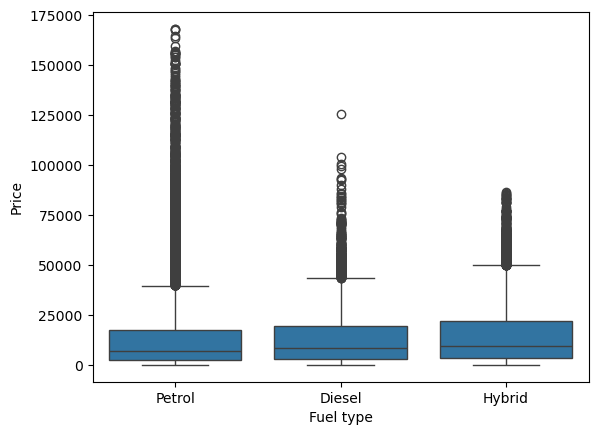

In [57]:
sns.boxplot(x="Fuel type", y ="Price", data = df)
plt.show()

# Step 3: Encoding (One Hot)

In [58]:
df = pd.get_dummies(df, columns=["Fuel type"], drop_first =True)

In [59]:
df

,Manufacturer,Model,Engine size,Year of manufacture,Mileage,Price,Fuel type_Hybrid,Fuel type_Petrol
0,Ford,Fiesta,1.0,2002,127300,3074,False,True
1,Porsche,Cayman,4.0,2016,57850,49704,False,True
2,Ford,Mondeo,1.6,2014,39190,24072,False,False
3,Toyota,RAV4,1.8,1988,210814,1705,True,False
4,VW,Polo,1.0,2006,127869,4101,False,True
...,...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,2018,28664,113006,False,True
49996,Toyota,Prius,1.8,2003,105120,9430,True,False
49997,Ford,Mondeo,1.6,2022,4030,49852,False,False
49998,Ford,Focus,1.0,2016,26468,23630,False,False


# Step 4: Find Correlation

In [60]:
relation = df.corr(numeric_only=True)

<function matplotlib.pyplot.show(close=None, block=None)>

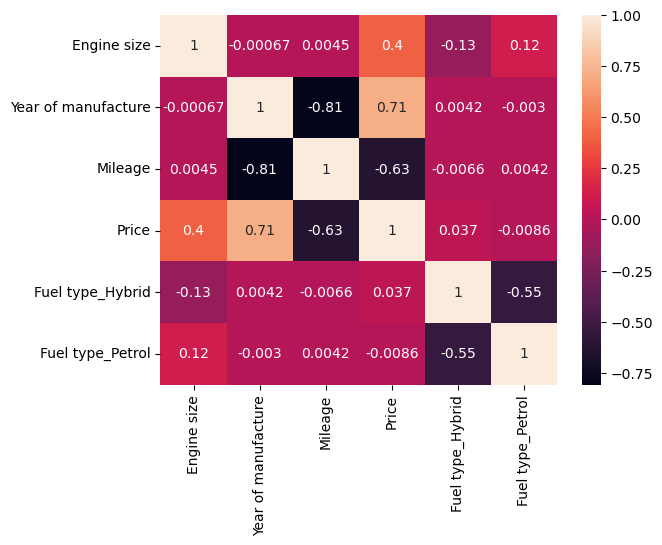

In [61]:
sns.heatmap(relation,annot = True)
plt.show

# Step 5: Feature Selection

In [62]:
x = df.drop("Price",axis =1)
y = df["Price"]

# Step 6: Train Test Split

In [79]:
from sklearn.model_selection import train_test_split as tts

X=df.drop(["Manufacturer","Model","Price"] , axis = 1)
y = df["Price"]

X_train, x_test, y_train, y_test = tts(X, y, test_size =0.2, random_state = 42)

In [80]:
X.head()

,Engine size,Year of manufacture,Mileage,Fuel type_Hybrid,Fuel type_Petrol
0,1.0,2002,127300,False,True
1,4.0,2016,57850,False,True
2,1.6,2014,39190,False,False
3,1.8,1988,210814,True,False
4,1.0,2006,127869,False,True


In [81]:
y.head()

0     3074
1    49704
2    24072
3     1705
4     4101
Name: Price, dtype: int64

# Step 6: Model Training (Linear Regression)

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor()
model = LinearRegression()
model.fit(X_train, y_train)
model2.fit(X_train, y_train)

RandomForestRegressor()

# Step 7: Prediction

In [92]:
y_pred = model.predict(x_test)
y_pred2 =model2.predict(x_test)

# Step 8: Model Evaluation

In [95]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("Linear Regression")
print("R2 score:", r2_score(y_test, y_pred))
print("MAE:" ,mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

print("\nRandom Forest")
print("R2 score:", r2_score(y_test, y_pred2))
print("MAE:" ,mean_absolute_error(y_test, y_pred2))
print("MSE:", mean_squared_error(y_test, y_pred2))

Linear Regression
R2 score: 0.6785891212654533
MAE: 5981.620961308029
MSE: 87222946.59119698

Random Forest
R2 score: 0.9462332899931656
MAE: 1643.3285903761905
MSE: 14590952.533326386
